# Job Application Assistant

In this workflow, we are going to build a simple job application assistant using the Prompt Chaining pattern. The goal is to help a user create a personalized cover letter from a given job description.

## Import Packages

In [13]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph
import ollama

## Helper function: Print Workflow


In [1]:
def print_workflow_info(workflow, app=None):
    """Prints comprehensive information about a LangGraph workflow."""
    print("WORKFLOW INFORMATION")
    print("====================")
    print(f"Nodes: {workflow.nodes}")
    print(f"Edges: {workflow.edges}")

    
    # Use getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"Finish points: {finish_points}")
    except:
        try:
            # Alternative approaches
            print(f"Finish point: {workflow._finish_point}")
        except:
            print("Finish points attribute not directly accessible")
    
    if app:
        print("\nWorkflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

## Step 1: Define State Class

In [15]:
class ChainState(TypedDict):
    job_description: str
    resume_summary: str
    cover_letter: str


state = ChainState()

print(type(state))

print(state)

#instance of state
state_1 = {
    "job_description": "We are looking for passionate Research Scientists to join our core AI pillars. This unified role covers three of our most critical research areas. Depending on your expertise and interest, you will join one of the following teams:Language AI: Building the world's leading translation and text-improvement systems, taking responsibility for the entire model lifecycle from data to deployment. Foundation Model Task Adaptation (FMTA): Shaping how our models learn beyond pre-training. You will focus on RLHF, alignment, and post-training to enable new reasoning and controllability capabilities.",
    "resume_summary": "",
    "cover_letter" : ""
    }

print(state_1)

state["job_description"] = "Data scientist"
print(state)


<class 'dict'>
{}
{'job_description': "We are looking for passionate Research Scientists to join our core AI pillars. This unified role covers three of our most critical research areas. Depending on your expertise and interest, you will join one of the following teams:Language AI: Building the world's leading translation and text-improvement systems, taking responsibility for the entire model lifecycle from data to deployment. Foundation Model Task Adaptation (FMTA): Shaping how our models learn beyond pre-training. You will focus on RLHF, alignment, and post-training to enable new reasoning and controllability capabilities.", 'resume_summary': '', 'cover_letter': ''}
{'job_description': 'Data scientist'}


## Step 2: Define Agent Nodes


* Each node is an agent, made up of a LLM with a persona and role. The role is defined by a prompt.
* The agent is given a persona ("You're a professional resume assistant") and a task ("Please summarize..."), hence,
    the of Instructions ("system role) and Input Data (user role)

### Agent Node1: Resume Summary Agent Node

In [ ]:
def generate_resume_summary(state: ChainState) -> ChainState:
    """
    Defines an agent node to generate resume summary. 
    
    """
    resume_llm_response= ollama.chat(
        model="llama3.2-vision:11b",
        messages=[
        {
            "role": "system", 
            "content": "You are a professional resume assistant. Your task is to summarize job descriptions from the perspective of a strong applicant's resume summary."
        },
        {
            "role": "user", 
            "content": f"Please summarize this job description:\n\n{state['job_description']}"
        }
        ]
        )

    llm_response = resume_llm_response['message']['content'].strip()

    return {**state, "resume_summary": llm_response}

In [28]:
resume_state = generate_resume_summary(state_1)

print(generate_resume_summary(state_1)["resume_summary"])

Here is a summary of the job description from the perspective of a strong applicant's resume summary:

**Results-driven Research Scientist** with expertise in AI and machine learning. Proven track record of developing and deploying cutting-edge AI models, with a focus on **natural language processing** and **model adaptation**. Skilled in **model lifecycle management**, including data preparation, model training, and deployment. Experienced in **RLHF and alignment** to improve model reasoning and controllability capabilities. Seeking to leverage expertise to drive innovation and advance AI research in a unified and collaborative environment.


### Agent Node 2: Cover Letter Agent Node

In [27]:
def generate_cover_letter(state: ChainState) -> ChainState:

    cover_letter_llm = ollama.chat(
        model="llama3.2-vision:11b",

        messages=[
            {
                "role": "system",
                "content": "You're a cover letter writing assistant. Your task is to write a professional and personalized cover letter for a job application."
            },
            {
                "role": "user",
                "content": f"""Please draft a cover letter for the job description:\n\n {state['job_description']}  using the resume:\n\n{state["resume_summary"]}"""
            }
        ]
    )
    #clean llm response
    llm_response = cover_letter_llm['message']['content'].strip()

    return {**state, "cover_letter": llm_response}



In [29]:
cover_letter_state = generate_cover_letter(resume_state)

print(cover_letter_state['cover_letter'])

Here's a draft cover letter based on the provided job description and the strong applicant's resume summary:

Dear Hiring Manager,

I am excited to apply for the Research Scientist position at [Company Name], where I can leverage my expertise in AI and machine learning to drive innovation in language AI and model adaptation. With a proven track record of delivering results-driven research, I am confident that my skills and experience make me an ideal fit for this unified research role.

As a seasoned Research Scientist, I have a deep understanding of the complexities involved in building and deploying large-scale models. My expertise in data preparation, model development, and post-training optimization has enabled me to drive breakthroughs in AI and machine learning. I am particularly drawn to [Company Name]'s commitment to pushing the boundaries of language AI and model adaptation, and I am excited about the prospect of joining a team that shares my passion for innovation.

With my p

## Step 3: Define LangGraph Workflow

### Initialize workflow with state


In [44]:
workflow = StateGraph(ChainState)

### Add Nodes to Workflow

In [45]:
## add resume summary node
workflow.add_node("resume_summary_node", generate_resume_summary)

#add cover letter node
workflow.add_node("cover_letter_node", generate_cover_letter)

### Add Edges to Workflow to connect Nodes

In [46]:
#edge to connect resume_summary_node and cover_letter_node
workflow.add_edge("resume_summary_node", "cover_letter_node")


### Set Workflow Entry Point

In [47]:
#set entry point to resume_summary_state
workflow.set_entry_point("resume_summary_node")

### Set Workflow End Point

In [48]:
workflow.set_finish_point("cover_letter_node")

### Display Workflow Information

In [49]:
print_workflow_info(workflow)

WORKFLOW INFORMATION
Nodes: {'resume_summary_node': StateNodeSpec(runnable=resume_summary_node(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None, input=<class '__main__.ChainState'>, retry_policy=None, ends=()), 'cover_letter_node': StateNodeSpec(runnable=cover_letter_node(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None, input=<class '__main__.ChainState'>, retry_policy=None, ends=())}
Edges: {('__start__', 'resume_summary_node'), ('cover_letter_node', '__end__'), ('resume_summary_node', 'cover_letter_node')}
Finish points attribute not directly accessible


### Compile Workflow

In [50]:
app = workflow.compile()

### Visualize Workflow

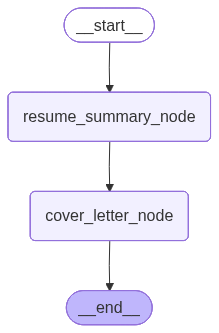

In [52]:
from IPython.display import Image, display

# Using mermaid instead of png
display(Image(app.get_graph().draw_mermaid_png()))

### Run App with User Query

In [53]:
input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = app.invoke(input_state)

In [54]:
result['resume_summary']

'Here\'s a summary of the job description from the perspective of a strong applicant\'s resume summary:\n\n"Results-driven data scientist with expertise in machine learning, NLP, and Python. Proven track record of successfully working with large datasets to drive business insights and deploying models into production to drive actionable results."'